# Week 4 Introduction — Determinants, Eigenvectors, and PCA

*Course notes for **Math for Machine Learning**, C1 · W4 · L1 · V01 — "Machine Learning Motivation" (DeepLearning.AI).*

A motivating overview of Week 4, which continues to view linear algebra **through the lens of linear transformations**. The week builds toward one of linear algebra's most powerful ML applications — **Principal Component Analysis (PCA)**. The roadmap:

- **Lesson 1 — Characterizing a transformation with the determinant:** singular vs. non-singular transformations, the **determinant as a stretch/shrink factor** (area change), and its properties under products and inverses.
- **Lesson 2 — Toward PCA:** **basis**, **span**, and **eigenvectors / eigenvalues**, ending with **PCA** for dimensionality reduction.

This notebook previews each idea with a small runnable demo. The formal treatment comes in the following videos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
%matplotlib inline

## 1. The destination: PCA (dimensionality reduction)

Imagine a data set of points in 2D that all lie **close to a single line**. PCA finds that line and **projects** every point onto it — turning a 2D data set into a **1D** one that keeps almost all the information. That's why it's a **dimensionality reduction** algorithm: fewer columns, more compact, easier to visualize, with minimal loss.

Below: a cloud of points hugging a direction, and their projection onto the principal line PCA would discover.

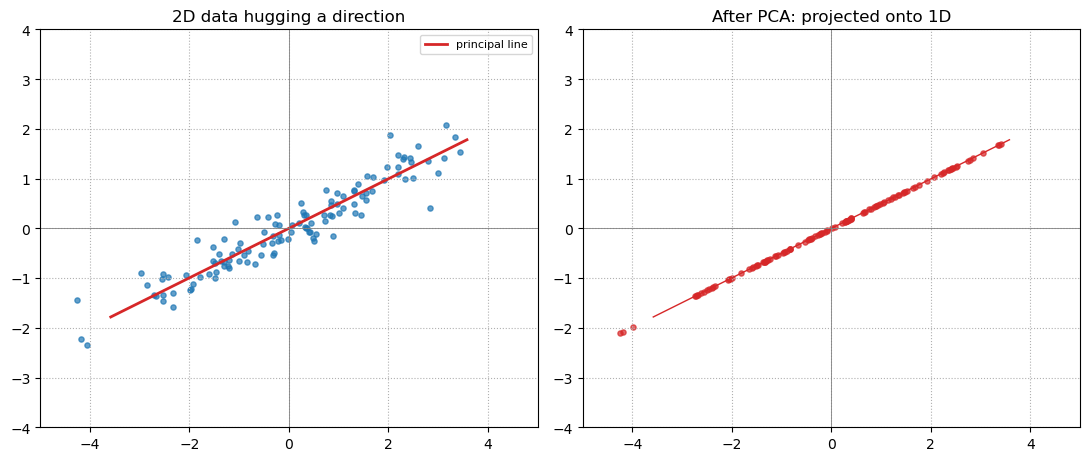

variance kept by PC1: 98.3%


In [2]:
# Make a 2D cloud that hugs a direction (reproducible without Math.random-style calls)
rng = np.random.default_rng(0)
n = 120
t = rng.normal(0, 1, n)                       # spread along the main direction
direction = np.array([2.0, 1.0]); direction /= np.linalg.norm(direction)
noise = rng.normal(0, 0.25, (n, 2))
pts = t[:, None] * direction * 2.0 + noise    # n x 2

# PCA via the top eigenvector of the covariance matrix
pts_c = pts - pts.mean(axis=0)
cov = np.cov(pts_c.T)
eigvals, eigvecs = np.linalg.eigh(cov)
pc1 = eigvecs[:, np.argmax(eigvals)]          # principal direction

# project each centered point onto pc1
proj_coord = pts_c @ pc1
proj = proj_coord[:, None] * pc1              # back in 2D, on the line

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(pts_c[:, 0], pts_c[:, 1], s=14, color='C0', alpha=0.7)
line = np.outer(np.linspace(-4, 4, 2), pc1)
axes[0].plot(line[:, 0], line[:, 1], 'C3', lw=2, label='principal line')
axes[0].set_title('2D data hugging a direction'); axes[0].legend(fontsize=8)

axes[1].scatter(proj[:, 0], proj[:, 1], s=14, color='C3', alpha=0.7)
axes[1].plot(line[:, 0], line[:, 1], 'C3', lw=1)
axes[1].set_title('After PCA: projected onto 1D')
for ax in axes:
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_xlim(-5, 5); ax.set_ylim(-4, 4)
plt.tight_layout(); plt.show()

print('variance kept by PC1: {:.1%}'.format(eigvals.max() / eigvals.sum()))

## 2. Lesson 1 preview: singular vs. non-singular transformations

A linear transformation can be **non-singular** (maps the plane onto the full plane) or **singular** (collapses the plane onto a line — a lower dimension). This is the same **singularity** you met with matrix inverses, now seen geometrically.

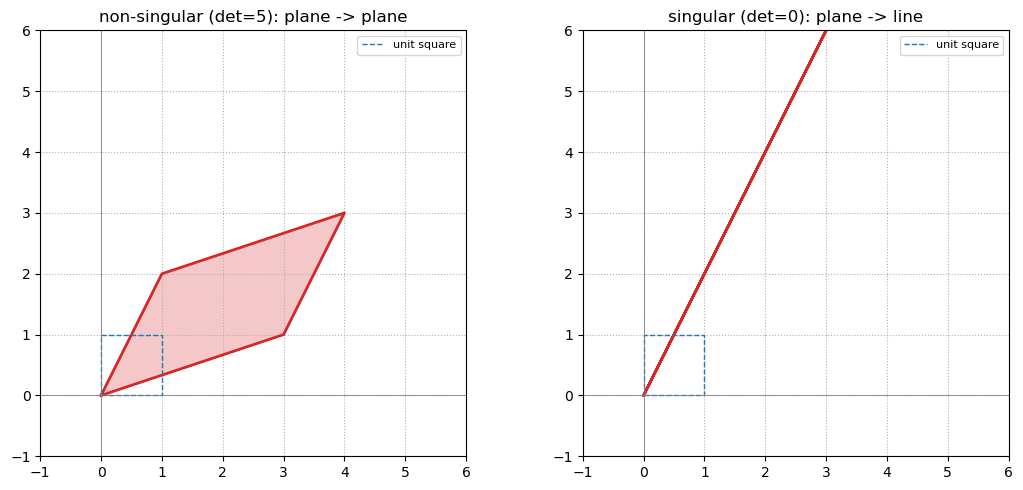

In [3]:
square = np.array([[0, 0], [1, 0], [1, 1], [0, 1], [0, 0]]).T
N = np.array([[3, 1], [1, 2]])   # non-singular
S = np.array([[1, 2], [2, 4]])   # singular (rows/cols proportional)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, Mx, ttl in [(axes[0], N, f'non-singular (det={np.linalg.det(N):.0f}): plane -> plane'),
                    (axes[1], S, f'singular (det={np.linalg.det(S):.0f}): plane -> line')]:
    img = Mx @ square
    ax.fill(img[0], img[1], color='C3', alpha=0.25); ax.plot(img[0], img[1], 'C3', lw=2)
    ax.plot(square[0], square[1], 'C0', ls='--', lw=1, label='unit square')
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_aspect('equal'); ax.grid(True, ls=':'); ax.set_title(ttl); ax.legend(fontsize=8)
    ax.set_xlim(-1, 6); ax.set_ylim(-1, 6)
plt.tight_layout(); plt.show()

## 3. Lesson 1 preview: the determinant measures stretch/shrink

Transformations **stretch or shrink** space, and the **determinant quantifies by how much** — it is the factor by which **area** changes (the area of the image of the unit square). A determinant of $0$ means the area collapsed to nothing (singular).

The week also covers intuitive **properties**: e.g. $\det(AB) = \det(A)\det(B)$ (useful for a cascade of transformations) and $\det(A^{-1}) = 1/\det(A)$ (useful for inverses).

In [4]:
A = np.array([[3, 1], [1, 2]])
B = np.array([[2, 0], [0, 2]])
print('det(A)        =', np.linalg.det(A), ' -> unit square area scales by ~5')
print('det(B)        =', np.linalg.det(B), ' -> area scales by 4 (doubles each side)')
print()
print('det(A@B)      =', round(np.linalg.det(A @ B), 3))
print('det(A)*det(B) =', round(np.linalg.det(A) * np.linalg.det(B), 3), ' (equal!)')
print('det(inv(A))   =', round(np.linalg.det(np.linalg.inv(A)), 3),
      ' vs 1/det(A) =', round(1/np.linalg.det(A), 3))

det(A)        = 5.000000000000001  -> unit square area scales by ~5
det(B)        = 4.0  -> area scales by 4 (doubles each side)

det(A@B)      = 20.0
det(A)*det(B) = 20.0  (equal!)
det(inv(A))   = 0.2  vs 1/det(A) = 0.2


## 4. Lesson 2 preview: eigenvectors as special directions

Most vectors change **direction** when you apply a matrix. An **eigenvector** is a special direction that the matrix **keeps pointing the same way** — applying the transformation just **scales** it by a constant, the **eigenvalue**:

$$ A v = \lambda v. $$

Eigenvectors quickly **characterize** a transformation and are the mathematical heart of **PCA** (the principal line in section 1 is exactly the top eigenvector of the data's covariance).

eigenvalues : [3. 1.]
eigenvectors (columns):
[[ 0.707 -0.707]
 [ 0.707  0.707]]


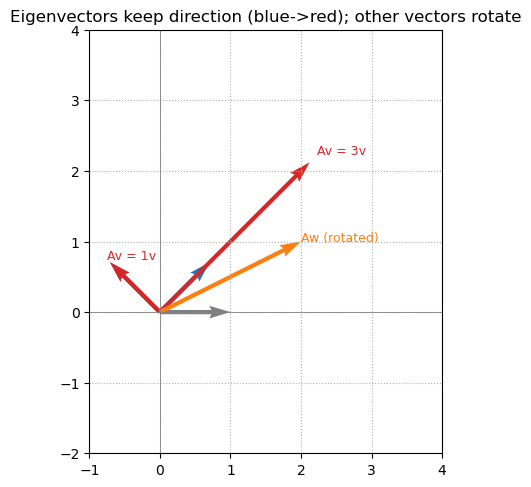

In [5]:
A = np.array([[2, 1], [1, 2]])
eigvals, eigvecs = np.linalg.eig(A)
print('eigenvalues :', eigvals)
print('eigenvectors (columns):')
print(eigvecs)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
opts = dict(angles='xy', scale_units='xy', scale=1, width=0.012)
for i in range(2):
    v = eigvecs[:, i]; lam = eigvals[i]
    ax.quiver(0, 0, v[0], v[1], color='C0', **opts)
    ax.quiver(0, 0, *(A @ v), color='C3', **opts)
    ax.text(*(A @ v * 1.05), f'Av = {lam:.0f}v', color='C3', fontsize=9)
# a non-eigen vector changes direction
w = np.array([1, 0])
ax.quiver(0, 0, *w, color='C7', **opts)
ax.quiver(0, 0, *(A @ w), color='C1', **opts)
ax.text(*(A @ w), 'Aw (rotated)', color='C1', fontsize=9)
ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
ax.set_aspect('equal'); ax.grid(True, ls=':')
ax.set_xlim(-1, 4); ax.set_ylim(-2, 4)
ax.set_title('Eigenvectors keep direction (blue->red); other vectors rotate')
plt.show()

## Summary

- Week 4 characterizes linear transformations and applies them to ML, culminating in **PCA**.
- **Lesson 1:** the **determinant** distinguishes **singular** (area collapses to $0$, plane $\to$ line) from **non-singular** transformations, and measures how much a transformation **stretches or shrinks area**; it has clean properties like $\det(AB)=\det(A)\det(B)$ and $\det(A^{-1})=1/\det(A)$.
- **Lesson 2:** **basis** and **span** describe which space a set of vectors generates; **eigenvectors** are directions preserved by a matrix ($Av=\lambda v$), and they power **PCA** for dimensionality reduction.